# 03 — Command Investigation (H1)

Implements `h1_design_spec.md` exactly. Every design choice is logged in `decisions.md`.
This notebook produces results only — interpretation belongs to the project owner.

**Chain under test:** (a) two-strike putaway fails → (b) he expands for a chase → (c) hitters don't bite → (d) walk → (e) walks decide good vs. 3+ run starts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

RAW = Path("../data/raw")
FIG = Path("../figures")
B = 10_000
rng = np.random.default_rng(11)
pd.set_option("display.width", 200)

WHIFF = {"swinging_strike", "swinging_strike_blocked", "missed_bunt"}
SWING = WHIFF | {"foul", "foul_tip", "foul_bunt", "bunt_foul_tip", "hit_into_play"}
STRIKEOUT = {"strikeout", "strikeout_double_play"}

## Load pitch data and assign groups
Spring training excluded. Start = appearance beginning in the 1st inning. Fresh starter = every PA that begins within a start's first 15 pitches, played out in full. Intentional-walk PAs dropped before pitch numbering.

In [2]:
def load_pitcher(name, seasons):
    d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
                   for y in seasons], ignore_index=True)
    d = d[d.game_type != "S"]
    d["pa_id"] = d.game_pk.astype(str) + "_" + d.at_bat_number.astype(str)
    d = d[~d.pa_id.isin(d.loc[d.events == "intent_walk", "pa_id"])]
    d = d.sort_values(["game_pk", "at_bat_number", "pitch_number"]).reset_index(drop=True)
    first_inning = d.groupby("game_pk").inning.transform("min")
    d["role"] = np.where(first_inning == 1, "start", "relief")
    d["n"] = d.groupby("game_pk").cumcount() + 1
    d["pa_n0"] = d.groupby("pa_id").n.transform("min")
    d["group"] = np.where(d.role == "relief", "Relief",
                          np.where(d.pa_n0 <= 15, "Fresh starter", "Rest of starts"))
    d["pitcher_name"] = name
    return d

sas = load_pitcher("sasaki", [2025, 2026])
yam = load_pitcher("yamamoto", [2024, 2025, 2026])
yam = yam[yam.role == "start"]  # benchmark uses starts only
pitches = pd.concat([sas, yam], ignore_index=True)
pitches.groupby(["pitcher_name", "group"]).agg(games=("game_pk", "nunique"), PAs=("pa_id", "nunique"), pitches=("n", "size"))

/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_10240/2091590408.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_10240/2091590408.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_10240/2091590408.py

/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_10240/2091590408.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["pa_id"] = d.game_pk.astype(str) + "_" + d.at_bat_number.astype(str)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_10240/2091590408.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["role"] = np.where(first_inning == 1, "start", "relief")
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_10240/2091590408.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usua

games   PAs  pitches
pitcher_name group                               
sasaki       Fresh starter      31   127      503
             Relief             14    61      239
             Rest of starts     31   540     2148
yamamoto     Fresh starter      85   348     1450
             Rest of starts     85  1624     6326

## Hitter quality tiers
Same-season xwOBA, regressed toward league average with K = 100 PA, split at the league PA-weighted median.

In [3]:
tiers = []
for y in [2024, 2025, 2026]:
    x = pd.read_csv(RAW / f"batter_xwoba_{y}.csv")
    lg = (x.est_woba * x.pa).sum() / x.pa.sum()
    x["adj_xwoba"] = (x.pa * x.est_woba + 100 * lg) / (x.pa + 100)
    s = x.sort_values("adj_xwoba")
    median = s.adj_xwoba[(s.pa.cumsum() / s.pa.sum()) >= 0.5].iloc[0]
    x["tier"] = np.where(x.adj_xwoba >= median, "High", "Low")
    tiers.append(x[["player_id", "adj_xwoba", "tier"]].assign(season=y))
    print(f"{y}: league xwOBA {lg:.3f}, median cut {median:.3f}")
tiers = pd.concat(tiers)

pitches = pitches.merge(tiers, left_on=["batter", "season"], right_on=["player_id", "season"], how="left")
print("Pitches with no batter tier:", pitches.tier.isna().sum())

2024: league xwOBA 0.316, median cut 0.314
2025: league xwOBA 0.316, median cut 0.318
2026: league xwOBA 0.314, median cut 0.315
Pitches with no batter tier: 0


## Pitch flags and attack-zone bands
Bands by % of center-to-edge distance: heart < 67, shadow 67–133, chase 133–200, waste > 200 (Savant attack zones, computed from plate location and batter zone height). Pitchouts and pitches missing location are dropped from pitch-level metrics.

In [4]:
BALL_R = 1.45 / 12
half_w = (17 / 2) / 12 + BALL_R
z_mid = (pitches.sz_top + pitches.sz_bot) / 2
half_h = (pitches.sz_top - pitches.sz_bot) / 2 + BALL_R
pitches["x_pct"] = pitches.plate_x / half_w
pitches["z_pct"] = (pitches.plate_z - z_mid) / half_h
edge = np.maximum(pitches.x_pct.abs(), pitches.z_pct.abs())
pitches["band"] = np.select([edge < 0.67, edge < 1.33, edge < 2.0], ["Heart", "Shadow", "Chase"], "Waste")

pitches["swing"] = pitches.description.isin(SWING)
pitches["whiff"] = pitches.description.isin(WHIFF)
pitches["is_k"] = pitches.events.isin(STRIKEOUT)
pitches["ooz"] = pitches.zone >= 11
pitches["two_k_choice"] = (pitches.strikes == 2) & (pitches.balls < 3)  # 0-2, 1-2, 2-2

P = pitches[(pitches.description != "pitchout") & pitches.plate_x.notna() & pitches.zone.notna()].copy()

PA = (pitches.groupby("pa_id")
      .agg(pitcher_name=("pitcher_name", "first"), group=("group", "first"), game_pk=("game_pk", "first"),
           tier=("tier", "first"), reached_2k=("strikes", lambda s: (s == 2).any()),
           walk=("events", lambda e: (e == "walk").any()))
      .reset_index())

/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_10240/1086930732.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pitches["x_pct"] = pitches.plate_x / half_w
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_10240/1086930732.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pitches["z_pct"] = (pitches.plate_z - z_mid) / half_h
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_10240/1086930732.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.

## Metric definitions (numerator / denominator per game × tier)

In [5]:
def counts(df, mask, num_col, name):
    sub = df[mask]
    g = sub.groupby(["pitcher_name", "group", "game_pk", "tier"])[num_col].agg(["sum", "size"])
    return g.rename(columns={"sum": f"{name}_num", "size": f"{name}_den"})

parts = [
    counts(P, P.strikes == 2, "is_k", "putaway"),
    counts(P, (P.strikes == 2) & P.swing, "whiff", "whiff2k"),
    counts(P, P.two_k_choice, "ooz", "ooz2k"),
    counts(P, P.strikes < 2, "ooz", "oozlt2"),
    counts(P.assign(is_waste=P.band == "Waste"), P.two_k_choice & P.ooz, "is_waste", "waste"),
    counts(P, P.two_k_choice & P.ooz & P.band.isin(["Shadow", "Chase"]), "swing", "chase"),
    counts(PA, PA.reached_2k, "walk", "bb2k"),
    counts(PA, PA.walk | ~PA.walk, "walk", "bb"),
    counts(PA, PA.walk, "reached_2k", "bbvia2k"),
]
T = pd.concat(parts, axis=1).fillna(0).reset_index()
BASE = ["putaway", "whiff2k", "ooz2k", "oozlt2", "waste", "chase", "bb2k", "bb", "bbvia2k"]

## Cluster bootstrap by game
Games are resampled (not pitches). Relief and start games are separate pools; fresh and rest-of-starts share the same resampled start games. Each metric is computed per tier, then tier-standardized as the 50/50 average of the two tiers.

In [6]:
def weights(games, reps):
    """Resample multiplicities: row 0 = observed (all ones), rows 1.. = bootstrap draws."""
    w = rng.multinomial(len(games), np.full(len(games), 1 / len(games)), size=reps)
    return np.vstack([np.ones(len(games)), w])

def group_rates(pitcher, groups, W, games):
    """Tier-standardized rate (%) per metric for the union of `groups`, for every weight row."""
    sub = T[(T.pitcher_name == pitcher) & T.group.isin(groups)]
    out = {}
    tier_rates = {}
    for m in BASE:
        per_tier = []
        for tier in ["Low", "High"]:
            t = sub[sub.tier == tier].groupby("game_pk")[[f"{m}_num", f"{m}_den"]].sum().reindex(games, fill_value=0)
            num, den = W @ t[f"{m}_num"].values, W @ t[f"{m}_den"].values
            with np.errstate(invalid="ignore", divide="ignore"):
                per_tier.append(np.where(den > 0, 100 * num / den, np.nan))
            tier_rates[(m, tier)] = (per_tier[-1][0], int(t[f"{m}_den"].sum()))
        out[m] = (per_tier[0] + per_tier[1]) / 2
    out["expansion_gap"] = out["ooz2k"] - out["oozlt2"]
    return out, tier_rates

GROUPS = {"Relief": ["Relief"], "Fresh starter": ["Fresh starter"], "Rest of starts": ["Rest of starts"],
          "All starts": ["Fresh starter", "Rest of starts"]}
res, tier_detail = {}, {}
for pitcher in ["sasaki", "yamamoto"]:
    pt = pitches[pitches.pitcher_name == pitcher]
    pools = {role: np.sort(pt.loc[pt.role == role, "game_pk"].unique()) for role in ["relief", "start"]}
    Ws = {role: weights(g, B) for role, g in pools.items() if len(g)}
    for gname, groups in GROUPS.items():
        role = "relief" if gname == "Relief" else "start"
        if role not in Ws:
            continue
        res[(pitcher, gname)], tier_detail[(pitcher, gname)] = group_rates(pitcher, groups, Ws[role], pools[role])

## Results by group (tier-standardized %, 95% CI)

In [7]:
LABELS = {"putaway": "(a) Putaway%", "whiff2k": "(a) 2K whiff% [stuff]", "expansion_gap": "(b) Expansion gap (pts)",
          "ooz2k": "(b)  OOZ% 0-2/1-2/2-2", "oozlt2": "(b)  OOZ% <2 strikes", "waste": "(c-i) Waste share",
          "chase": "(c-ii) Chase rate", "bb2k": "(d) 2K walk rate", "bb": "(d) Overall BB%",
          "bbvia2k": "(d) % of walks via 2K"}

def ci(arr):
    boot = arr[1:][~np.isnan(arr[1:])]
    return arr[0], np.percentile(boot, 2.5), np.percentile(boot, 97.5)

rows = []
for (pitcher, gname), r in res.items():
    for m, label in LABELS.items():
        est, lo, hi = ci(r[m])
        if m == "expansion_gap":
            ns = (tier_detail[(pitcher, gname)][("ooz2k", "Low")][1], tier_detail[(pitcher, gname)][("ooz2k", "High")][1])
        else:
            ns = (tier_detail[(pitcher, gname)][(m, "Low")][1], tier_detail[(pitcher, gname)][(m, "High")][1])
        rows.append({"pitcher": pitcher, "group": gname, "metric": label, "est": round(est, 1),
                     "ci_lo": round(lo, 1), "ci_hi": round(hi, 1), "n_low_tier": ns[0], "n_high_tier": ns[1],
                     "low_n": "LOW N" if min(ns) < 30 else ""})
results = pd.DataFrame(rows)
results.to_csv("../data/processed/h1_group_results.csv", index=False)
results.pivot_table(index="metric", columns=["pitcher", "group"], values="est", sort=False)

pitcher                 sasaki                                              yamamoto                          
group                   Relief Fresh starter Rest of starts All starts Fresh starter Rest of starts All starts
metric                                                                                                        
(a) Putaway%              21.7          23.1           17.9       18.2          17.0           23.3       22.4
(a) 2K whiff% [stuff]     21.5          31.4           22.4       23.1          19.6           25.5       24.6
(b) Expansion gap (pts)   12.8          22.2            9.3       11.0          16.6           11.4       12.3
(b)  OOZ% 0-2/1-2/2-2     65.9          72.7           59.5       61.4          61.8           59.4       60.0
(b)  OOZ% <2 strikes      53.1          50.4           50.3       50.3          45.2           48.0       47.6
(c-i) Waste share         29.7          12.4           22.3       21.0          25.9           15.2       16.8
(c-ii) Chase rate         57.7          50.1           53.1       51.7          42.5           49.3       48.3
(d) 2K walk rate           6.7          11.4           11.5       11.3          11.5            6.8        7.5
(d) Overall BB%            8.1           9.2           11.1       10.5           9.0            6.2        6.6
(d) % of walks via 2K     25.0          69.0           55.1       57.1          77.5           61.0       64.6

In [8]:
results[results.pitcher == "sasaki"].set_index(["metric", "group"]).sort_index(level=0, sort_remaining=False)

pitcher   est  ci_lo  ci_hi  n_low_tier  n_high_tier  low_n
metric                  group                                                                     
(a) 2K whiff% [stuff]   Relief          sasaki  21.5   10.0   37.5          19           16  LOW N
                        Fresh starter   sasaki  31.4   20.2   44.6          21           70  LOW N
                        Rest of starts  sasaki  22.4   18.4   26.6         212          184       
                        All starts      sasaki  23.1   19.4   26.8         233          254       
(a) Putaway%            Relief          sasaki  21.7   15.0   32.4          38           26  LOW N
                        Fresh starter   sasaki  23.1   15.6   32.3          31          116       
                        Rest of starts  sasaki  17.9   15.1   20.9         325          301       
                        All starts      sasaki  18.2   15.7   20.9         356          417       
(b)  OOZ% 0-2/1-2/2-2   Relief          sasaki  65.9   53.8   80.8          32           20  LOW N
                        Fresh starter   sasaki  72.7   61.2   81.8          23           85  LOW N
                        Rest of starts  sasaki  59.5   55.2   63.8         275          245       
                        All starts      sasaki  61.4   57.7   65.3         298          330       
(b)  OOZ% <2 strikes    Relief          sasaki  53.1   45.0   60.2          83           92       
                        Fresh starter   sasaki  50.4   44.3   56.9          78          278       
                        Rest of starts  sasaki  50.3   47.5   52.8         746          773       
                        All starts      sasaki  50.3   47.7   52.8         824         1051       
(b) Expansion gap (pts) Relief          sasaki  12.8    0.6   27.9          32           20  LOW N
                        Fresh starter   sasaki  22.2   10.0   32.6          23           85  LOW N
                        Rest of starts  sasaki   9.3    4.1   14.5         275          245       
                        All starts      sasaki  11.0    6.7   15.5         298          330       
(c-i) Waste share       Relief          sasaki  29.7   17.6   47.8          23           12  LOW N
                        Fresh starter   sasaki  12.4    5.9   21.2          18           57  LOW N
                        Rest of starts  sasaki  22.3   18.4   27.0         168          142       
                        All starts      sasaki  21.0   17.1   25.4         186          199       
(c-ii) Chase rate       Relief          sasaki  57.7   40.0   78.1          17            8  LOW N
                        Fresh starter   sasaki  50.1   36.8   65.4          17           46  LOW N
                        Rest of starts  sasaki  53.1   47.7   58.3         132          109       
                        All starts      sasaki  51.7   46.5   56.6         149          155       
(d) % of walks via 2K   Relief          sasaki  25.0    0.0   33.3           1            4  LOW N
                        Fresh starter   sasaki  69.0   30.0  100.0           3            7  LOW N
                        Rest of starts  sasaki  55.1   42.8   69.1          27           33  LOW N
                        All starts      sasaki  57.1   46.3   69.6          30           40       
(d) 2K walk rate        Relief          sasaki   6.7    0.0   13.6          20           15  LOW N
                        Fresh starter   sasaki  11.4    3.4   21.0          16           49  LOW N
                        Rest of starts  sasaki  11.5    8.4   15.1         146          142       
                        All starts      sasaki  11.3    8.6   14.2         162          191       
(d) Overall BB%         Relief          sasaki   8.1    0.0   16.4          30           31       
                        Fresh starter   sasaki   9.2    3.5   16.9          26          101  LOW N
                        Rest of starts  sasaki  11.1    8.5   14.0         267 

## Tier-level detail (Sasaki) — rate % and denominator per hitter tier

In [9]:
rows = []
for gname in GROUPS:
    for (m, tier), (rate, n) in tier_detail[("sasaki", gname)].items():
        rows.append({"group": gname, "metric": LABELS.get(m, m), "tier": tier, "rate": round(rate, 1), "n": n})
pd.DataFrame(rows).pivot_table(index="metric", columns=["group", "tier"], values=["rate", "n"], sort=False)

rate                                                                      n                                                                    
group                 Relief       Fresh starter       Rest of starts       All starts       Relief       Fresh starter        Rest of starts        All starts        
tier                     Low  High           Low  High            Low  High        Low  High    Low  High           Low   High            Low   High        Low    High
metric                                                                                                                                                                 
(a) Putaway%            39.5   3.8          29.0  17.2           17.2  18.6       18.3  18.2   38.0  26.0          31.0  116.0          325.0  301.0      356.0   417.0
(a) 2K whiff% [stuff]   36.8   6.2          42.9  20.0           23.1  21.7       24.9  21.3   19.0  16.0          21.0   70.0          212.0  184.0      233.0   254.0
(b)  OOZ% 0-2/1-2/2-2   71.9  60.0          78.3  67.1           61.1  58.0       62.4  60.3   32.0  20.0          23.0   85.0          275.0  245.0      298.0   330.0
(b)  OOZ% <2 strikes    53.0  53.3          48.7  52.2           48.8  51.7       48.8  51.9   83.0  92.0          78.0  278.0          746.0  773.0      824.0  1051.0
(c-i) Waste share       26.1  33.3           5.6  19.3           21.4  23.2       19.9  22.1   23.0  12.0          18.0   57.0          168.0  142.0      186.0   199.0
(c-ii) Chase rate       52.9  62.5          58.8  41.3           53.0  53.2       53.7  49.7   17.0   8.0          17.0   46.0          132.0  109.0      149.0   155.0
(d) 2K walk rate         0.0  13.3          12.5  10.2           10.3  12.7       10.5  12.0   20.0  15.0          16.0   49.0          146.0  142.0      162.0   191.0
(d) Overall BB%          3.3  12.9          11.5   6.9           10.1  12.1       10.2  10.7   30.0  31.0          26.0  101.0          267.0  273.0      293.0   374.0
(d) % of walks via 2K    0.0  50.0          66.7  71.4           55.6  54.5       56.7  57.5    1.0   4.0           3.0    7.0           27.0   33.0       30.0    40.0

## Pre-registered contrasts and verdicts (Sasaki)
Primary: all starts − relief. Decomposition: fresh − relief (role/effort), rest − fresh (fatigue).

In [10]:
S = {g: res[("sasaki", g)] for g in GROUPS}
CONTRASTS = {"All starts − Relief": ("All starts", "Relief"),
             "Fresh − Relief (role)": ("Fresh starter", "Relief"),
             "Rest − Fresh (fatigue)": ("Rest of starts", "Fresh starter")}

def verdict(m, est, lo, hi):
    if m == "putaway":
        return "Supported" if (hi < 0 and est <= -5) else ("Contradicted" if lo > 0 else "Inconclusive")
    if m == "whiff2k":
        if est <= -5 and hi < 0:
            return "Stuff declined"
        return "Stuff not shown to decline" if abs(est) < 5 else "Inconclusive"
    if m == "waste":
        return "Supported" if (lo > 0 and est >= 10) else ("Contradicted" if hi < 0 else "Inconclusive")
    if m == "chase":
        return "Points to stuff (H4)" if (hi < 0 and est <= -5) else "No stuff signal"
    if m == "bb2k":
        return "Supported" if (lo > 0 and est >= 4) else ("Contradicted" if hi < 0 else "Inconclusive")
    return ""

rows = []
for cname, (g1, g2) in CONTRASTS.items():
    for m in ["putaway", "whiff2k", "expansion_gap", "waste", "chase", "bb2k", "bb"]:
        diff = S[g1][m] - S[g2][m]
        est, lo, hi = ci(diff)
        rows.append({"contrast": cname, "metric": LABELS[m], "diff": round(est, 1), "ci_lo": round(lo, 1),
                     "ci_hi": round(hi, 1), "verdict": verdict(m, est, lo, hi) if cname.startswith("All") else ""})
contrasts = pd.DataFrame(rows)
contrasts.to_csv("../data/processed/h1_contrasts.csv", index=False)
contrasts

,contrast,metric,diff,ci_lo,ci_hi,verdict
0,All starts − Relief,(a) Putaway%,-3.4,-14.3,4.0,Inconclusive
1,All starts − Relief,(a) 2K whiff% [stuff],1.5,-15.1,14.0,Stuff not shown to decline
2,All starts − Relief,(b) Expansion gap (pts),-1.8,-17.7,11.4,
3,All starts − Relief,(c-i) Waste share,-8.7,-26.8,4.0,Inconclusive
4,All starts − Relief,(c-ii) Chase rate,-6.0,-27.0,12.3,No stuff signal
5,All starts − Relief,(d) 2K walk rate,4.6,-2.8,12.4,Inconclusive
6,All starts − Relief,(d) Overall BB%,2.3,-6.2,10.2,
7,Fresh − Relief (role),(a) Putaway%,1.5,-11.5,13.2,
8,Fresh − Relief (role),(a) 2K whiff% [stuff],9.9,-9.5,27.8,
9,Fresh − Relief (role),(b) Expansion gap (pts),9.4,-10.3,25.9,


In [11]:
# (b) descriptive check: expansion gap > 0 in starts
est, lo, hi = ci(S["All starts"]["expansion_gap"])
print(f"(b) Expansion gap in all starts: {est:.1f} pts [{lo:.1f}, {hi:.1f}] ->",
      "Supported (expands)" if lo > 0 else "Inconclusive")

(b) Expansion gap in all starts: 11.0 pts [6.7, 15.5] -> Supported (expands)


## Link (e): walks vs. contact quality in good (0–2 R) vs. bad (3+ R) starts

In [12]:
def start_table(name):
    logs = pd.read_csv(RAW / f"{name}_game_logs.csv")
    logs = logs[logs.gamesStarted == 1].copy()
    pt = pitches[pitches.pitcher_name == name]
    xcon = pt[pt.description == "hit_into_play"].groupby("game_pk").estimated_woba_using_speedangle.mean()
    logs["bb_pct"] = 100 * (logs.baseOnBalls - logs.intentionalWalks) / (logs.battersFaced - logs.intentionalWalks)
    logs["xwobacon"] = logs.game_pk.map(xcon)
    logs["bad"] = (logs.runs >= 3).astype(int)
    logs["pitcher_name"] = name
    return logs[["pitcher_name", "date", "game_pk", "runs", "inningsPitched", "battersFaced", "bb_pct", "xwobacon", "bad"]]

starts = pd.concat([start_table("sasaki"), start_table("yamamoto")], ignore_index=True)
starts.to_csv("../data/processed/h1_start_level.csv", index=False)
starts.groupby(["pitcher_name", "bad"]).agg(starts=("game_pk", "size"), mean_bb_pct=("bb_pct", "mean"),
                                             mean_xwobacon=("xwobacon", "mean"), mean_runs=("runs", "mean")).round(3)

starts  mean_bb_pct  mean_xwobacon  mean_runs
pitcher_name bad                                               
sasaki       0        16       12.797          0.328      1.375
             1        15        9.606          0.412      3.933
yamamoto     0        58        6.004          0.318      0.845
             1        27        9.399          0.385      3.963

In [13]:
def link_e(df):
    good, bad = df[df.bad == 0], df[df.bad == 1]
    out = {}
    for col in ["bb_pct", "xwobacon"]:
        g, b = good[col].dropna().values, bad[col].dropna().values
        def stats(gg, bb):
            pooled = np.sqrt(((len(gg) - 1) * gg.var(ddof=1) + (len(bb) - 1) * bb.var(ddof=1)) / (len(gg) + len(bb) - 2))
            return bb.mean() - gg.mean(), (bb.mean() - gg.mean()) / pooled
        obs = stats(g, b)
        boot = np.array([stats(rng.choice(g, len(g)), rng.choice(b, len(b))) for _ in range(B)])
        out[col] = {"diff": obs[0], "diff_lo": np.percentile(boot[:, 0], 2.5), "diff_hi": np.percentile(boot[:, 0], 97.5),
                    "std_diff": obs[1], "std_lo": np.percentile(boot[:, 1], 2.5), "std_hi": np.percentile(boot[:, 1], 97.5)}
    return pd.DataFrame(out).T.round(3)

for name in ["sasaki", "yamamoto"]:
    print(f"\n{name}: bad − good starts")
    print(link_e(starts[starts.pitcher_name == name]).to_string())


sasaki: bad − good starts


           diff  diff_lo  diff_hi  std_diff  std_lo  std_hi
bb_pct   -3.191   -8.967    2.173    -0.387  -1.039   0.338
xwobacon  0.084    0.040    0.129     1.286   0.642   2.212

yamamoto: bad − good starts


           diff  diff_lo  diff_hi  std_diff  std_lo  std_hi
bb_pct    3.395    0.863    6.025     0.645   0.171   1.211
xwobacon  0.067    0.021    0.111     0.690   0.217   1.197


In [14]:
e = link_e(starts[starts.pitcher_name == "sasaki"])
bb, xw = e.loc["bb_pct"], e.loc["xwobacon"]
passes = bb["diff"] >= 3 and bb["diff_lo"] > 0 and bb["std_diff"] > xw["std_diff"]
print("(e) verdict:", "Supported" if passes else ("Contradicted" if bb["diff_hi"] < 0 else "Not supported"),
      f"| BB% diff {bb['diff']:.1f} [{bb['diff_lo']:.1f}, {bb['diff_hi']:.1f}],",
      f"std diff BB% {bb['std_diff']:.2f} vs xwOBAcon {xw['std_diff']:.2f}")

(e) verdict: Not supported | BB% diff -3.2 [-8.9, 2.2], std diff BB% -0.39 vs xwOBAcon 1.29


In [15]:
# Secondary: logistic regression, bad start ~ z(BB%) + z(xwOBAcon). 31 starts -> rough check only.
d = starts[starts.pitcher_name == "sasaki"].dropna(subset=["bb_pct", "xwobacon"])
X = sm.add_constant(pd.DataFrame({"z_bb_pct": (d.bb_pct - d.bb_pct.mean()) / d.bb_pct.std(),
                                  "z_xwobacon": (d.xwobacon - d.xwobacon.mean()) / d.xwobacon.std()}))
fit = sm.Logit(d.bad, X).fit(disp=0)
pd.DataFrame({"coef": fit.params, "ci_lo": fit.conf_int()[0], "ci_hi": fit.conf_int()[1]}).round(2)

,coef,ci_lo,ci_hi
const,-0.24,-1.16,0.68
z_bb_pct,-0.52,-1.75,0.71
z_xwobacon,1.83,0.39,3.27


## Figure 1 — Chain ladder

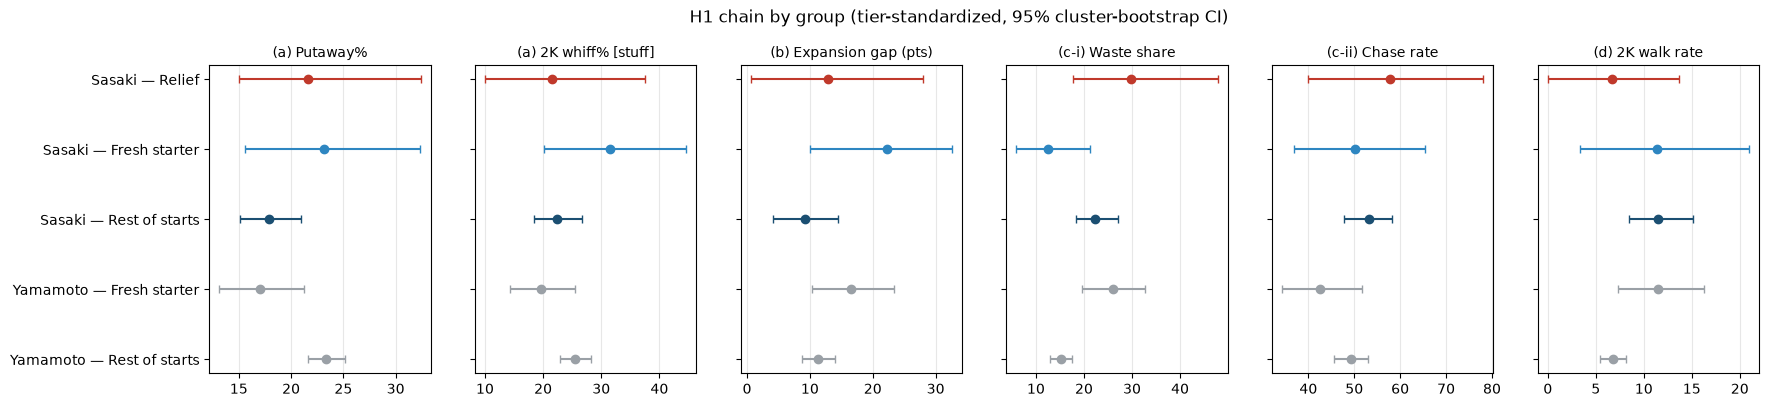

In [16]:
panels = ["putaway", "whiff2k", "expansion_gap", "waste", "chase", "bb2k"]
order = [("sasaki", "Relief"), ("sasaki", "Fresh starter"), ("sasaki", "Rest of starts"),
         ("yamamoto", "Fresh starter"), ("yamamoto", "Rest of starts")]
fig, axes = plt.subplots(1, len(panels), figsize=(20, 4), sharey=True)
for ax, m in zip(axes, panels):
    for i, key in enumerate(order):
        est, lo, hi = ci(res[key][m])
        color = "#9aa0a6" if key[0] == "yamamoto" else ["#c0392b", "#2e86c1", "#1b4f72"][i]
        ax.errorbar(est, i, xerr=[[est - lo], [hi - est]], fmt="o", color=color, capsize=3)
    ax.set_title(LABELS[m], fontsize=10)
    ax.grid(axis="x", alpha=0.3)
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels([f"{p.title()} — {g}" for p, g in order])
axes[0].invert_yaxis()
fig.suptitle("H1 chain by group (tier-standardized, 95% cluster-bootstrap CI)", y=1.02)
fig.savefig(FIG / "h1_chain_ladder.png", dpi=150, bbox_inches="tight")

## Figure 2 — Link (e): walks vs. contact quality per start

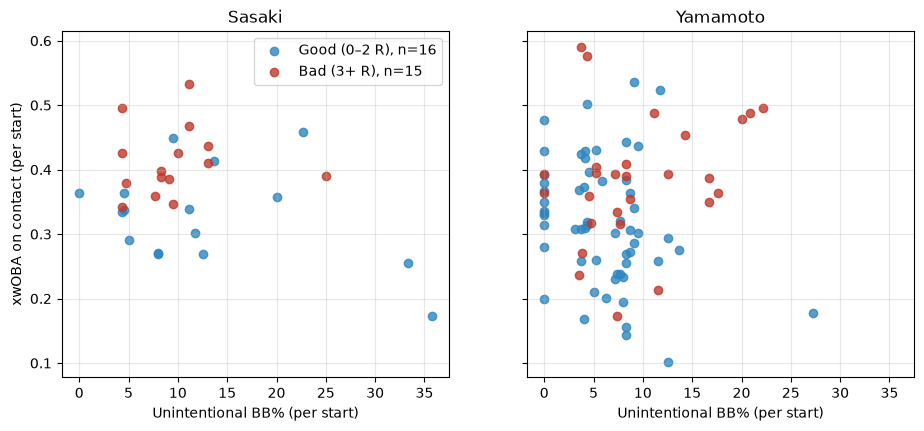

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, name in zip(axes, ["sasaki", "yamamoto"]):
    d = starts[starts.pitcher_name == name]
    for bad, color, label in [(0, "#2e86c1", "Good (0–2 R)"), (1, "#c0392b", "Bad (3+ R)")]:
        s = d[d.bad == bad]
        ax.scatter(s.bb_pct, s.xwobacon, color=color, label=f"{label}, n={len(s)}", alpha=0.8)
    ax.set_title(name.title())
    ax.set_xlabel("Unintentional BB% (per start)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("xwOBA on contact (per start)")
axes[0].legend()
fig.savefig(FIG / "h1_link_e_scatter.png", dpi=150, bbox_inches="tight")

## Figure 3 — Two-strike (0-2/1-2/2-2) out-of-zone pitch locations, Sasaki
Catcher's view, normalized so the zone edge = ±1. Squares mark the shadow (0.67–1.33), chase (to 2.0) band edges.

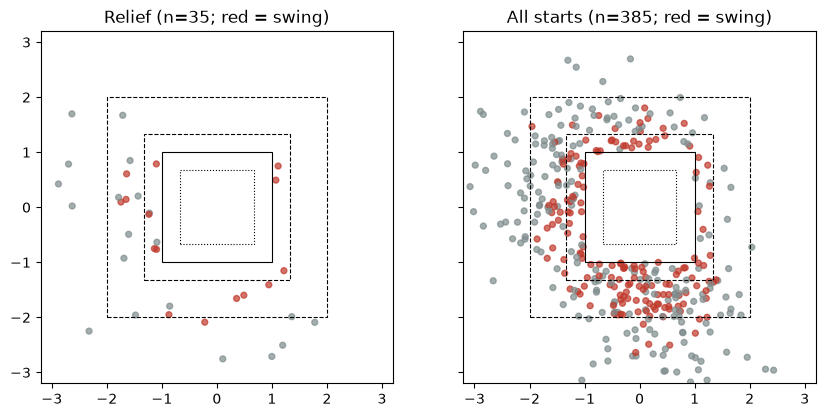

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
sp = P[(P.pitcher_name == "sasaki") & P.two_k_choice & P.ooz]
for ax, (title, mask) in zip(axes, [("Relief", sp.group == "Relief"), ("All starts", sp.group != "Relief")]):
    s = sp[mask]
    ax.scatter(s.x_pct, s.z_pct, c=np.where(s.swing, "#c0392b", "#7f8c8d"), s=18, alpha=0.7)
    for k, ls in [(0.67, ":"), (1.0, "-"), (1.33, "--"), (2.0, "--")]:
        ax.add_patch(plt.Rectangle((-k, -k), 2 * k, 2 * k, fill=False, ls=ls, color="black", lw=0.8))
    ax.set_title(f"{title} (n={len(s)}; red = swing)")
    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-3.2, 3.2)
    ax.set_aspect("equal")
fig.savefig(FIG / "h1_2k_ooz_locations.png", dpi=150, bbox_inches="tight")